# SIOC 251: Homework 3 — Part II
## Monte Carlo Radiative Transfer with Non-Isotropic Scattering

**Sophie Wynn**

---
## Setup

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

rng = np.random.default_rng(seed=42)

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'figure.dpi': 120,
})

Z_ATM     = 8500.0
N_PHOTONS = 100_000

print('Imports complete.')

Imports complete.


In [26]:
def sample_path_length(rng):
    """Draw an optical-depth path length from the exponential CDF."""
    zeta = rng.uniform(0.0, 1.0)
    return -np.log(1.0 - zeta)

def rotate_to_model_frame(k_in, cos_theta, phi):
    """Rotate a scattered direction from the photon frame to the model frame.
    Same as Part I (appendix procedure).
    """
    sin_theta = np.sqrt(max(0.0, 1.0 - cos_theta**2))
    kp = np.array([sin_theta * np.cos(phi),
                   sin_theta * np.sin(phi),
                   cos_theta])

    kx, ky, kz = k_in
    horiz = np.hypot(kx, ky)
    if horiz < 1e-12:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horiz

    zp = k_in
    yp = np.cross(zp, xp)

    k_new = kp[0] * xp + kp[1] * yp + kp[2] * zp
    return k_new / np.linalg.norm(k_new)

---
## Part II.1: Model Construction

### 6.1.a — Henyey-Greenstein phase function and CDF inversion

The Henyey-Greenstein phase function is
$$P_{\rm HG}(\cos\Theta) \;=\; \frac{1 - g^2}{(1 + g^2 - 2g\cos\Theta)^{3/2}}.$$


When I solved for cos(theta) I got: $$\boxed{\cos\Theta \;=\; \frac{1}{2g}\left[\,1 + g^2 \;-\; \left(\frac{1 - g^2}{1 - g + 2g\zeta}\right)^{\!2}\,\right] .}$$
See attached photos at the end of the notebook to see my work

In [27]:
# new cosine function sampling for HG phase function
def sample_scatter_angles_hg(g, rng):

    zeta = rng.uniform(0.0, 1.0)

    if abs(g) < 1e-6:
        # avoid divide-by-zero 
        cos_theta = 2.0 * zeta - 1.0
    else:
        inner = (1.0 - g**2) / (1.0 - g + 2.0 * g * zeta)
        cos_theta = (1.0 + g**2 - inner**2) / (2.0 * g)
        # Numerical safety: clip in case of tiny round-off outside [-1, 1]
        cos_theta = float(np.clip(cos_theta, -1.0, 1.0))

    phi = rng.uniform(0.0, 2.0 * np.pi)
    return cos_theta, phi

### 6.1.b — Multiple-scattering loop with HG phase function


In [28]:

# new main function for Part II: multiple scattering with HG phase function
def run_monte_carlo_hg(tau_star, sza_deg, omega, g,
                      n_photons=N_PHOTONS, rng=rng, n_traces=0):
    """HW3 Part II — multiple-scattering MC with HG phase function.

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : absorbed inside the atmosphere

    If n_traces > 0, records the (x, tau_pos) trajectory of the first n_traces
    photons and returns them under the 'trajectories' key (list of arrays).
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'g': g, 'mu0': mu0,
                'trajectories': []}

    # Initial photon direction in model coordinates (downward at SZA).
    # By azimuthal symmetry we can pick phi0 = 0 without loss of generality.
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct    = 0
    n_diffuse   = 0
    n_reflected = 0
    n_absorbed  = 0
    trajectories = []   # only filled for the first n_traces photons

    for i in range(n_photons):
        record_this = (i < n_traces)   # only the first n_traces photons get traced

        k         = k_init.copy()
        x         = 0.0    # horizontal position (only used when recording)
        tau_pos   = 0.0      # vertical optical depth so far (0 = TOA, tau_star = surface), The photon's vertical position in the atmosphere — how deep it is, measured from the top
        scattered = False    # has this photon ever scattered?
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            # --- sample optical path length along current direction ---
            ds = sample_path_length(rng) #The path length the photon just traveled, along its direction of motion

            # --- convert along-path tau to a vertical-tau increment ---
            # k[2] < 0 means heading down (tau_pos increases)
            # k[2] > 0 means heading up   (tau_pos decreases)
            #
            dtau_vert  = -ds * k[2] ; #down = positive depth thats where the negative comes in; and here dtau_vert vertical depth change for this step 
            tau_pos_n  = tau_pos + dtau_vert # adds the change to the current vertical position to get the proposed new vertical depth.
            dx         =  ds * k[0]    # horizontal displacement (only used when recording)
            x_n        = x + dx

            # --- escape checks BEFORE the interaction would have occurred ---
            if tau_pos_n >= tau_star: #Did the photon make it to the surface this step?
                # exits the bottom → reaches surface
                if record_this:
                    # clip the last segment to land exactly on tau = tau_star
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1 #+= 1 is shorthand for "add 1 to whatever this variable currently is and store the result back
                else:
                    n_direct += 1
                break
            if tau_pos_n <= 0.0: #Did the photon escape out the top? (only possible after a scatter)
                # exits the top → reflected to space (only possible after a scatter)
                if record_this:
                    # clip the last segment to land exactly on tau = 0
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- otherwise the photon interacts inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?
            if rng.uniform(0.0, 1.0) >= omega: #Random number for scatter-vs-absorb
                n_absorbed += 1
                break

            # 5.1.b–c: sample new scattering angles
            cos_th, phi = sample_scatter_angles_hg(g, rng)

            # 5.1.d: rotate into model coordinates -> new propagation direction
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True
            # 5.1.e: loop continues — sample a new path length next iteration

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,   # list of (Npts, 2) arrays; empty if n_traces=0
    'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'g': g, 'mu0': mu0,
    }

---
## Part II.2: Verification

**6.2.a:** 
- $g = 0$ should reproduce the isotropic
- $g \to 1$  should produce trajectories that behave like the no-scattering case (every "scatter" continues forward).
- $g \to -1$  should produce trajectories that reverse direction on every scatter.

**To do this I will create a subplot of the three trajectories for each g value, when g = +- 1 I don't see any tragjectories  so I set g = +/- 0.99**

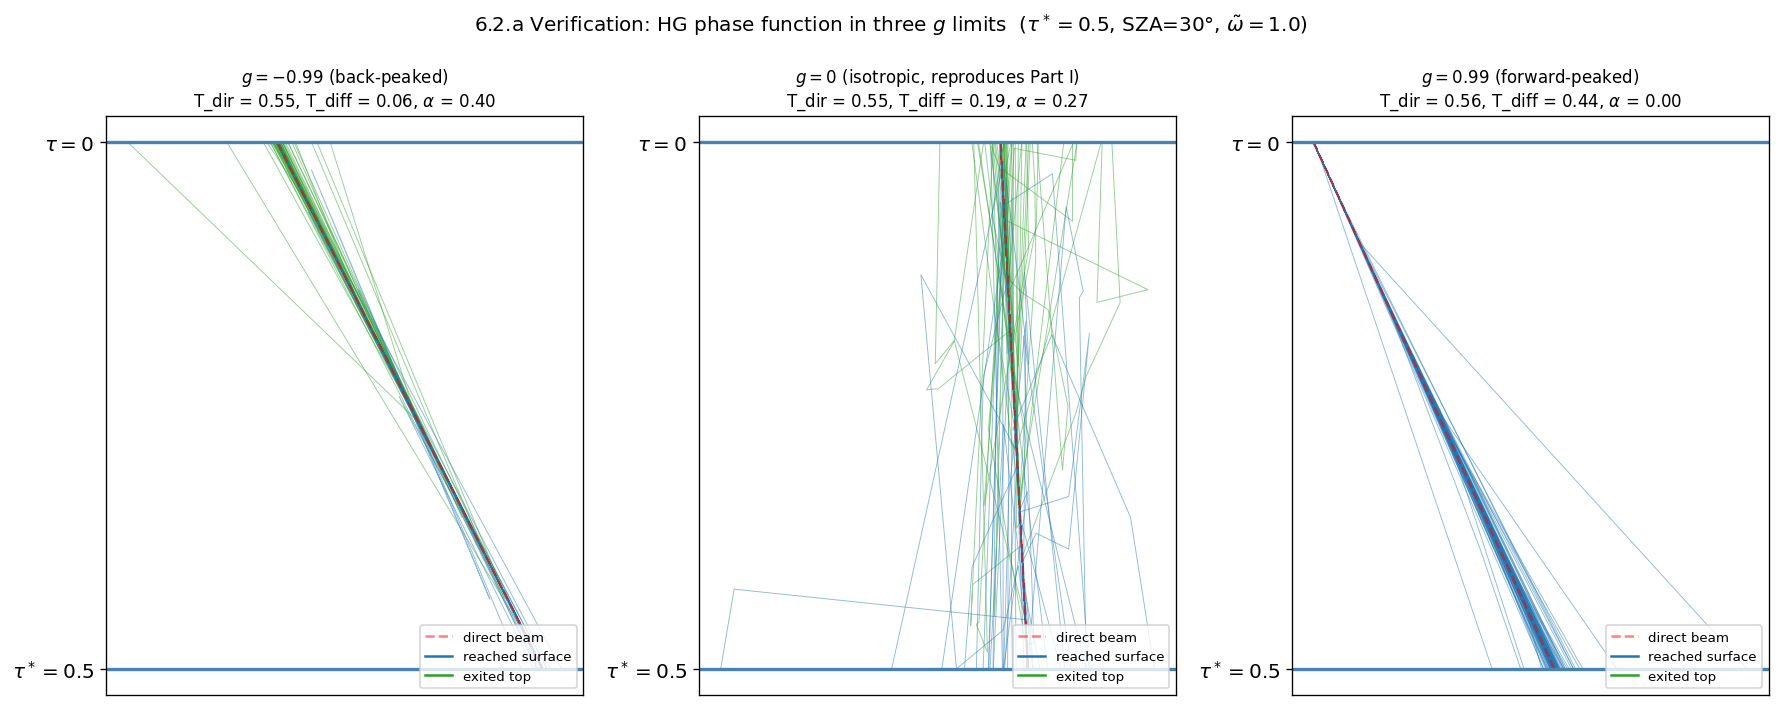

In [29]:
# --- Verification test 6.2.a: trajectory comparison across three g limits ---
import matplotlib.pyplot as plt
tau_star = 0.5   
sza_deg  = 30.0
omega    = 1.0     # pure scattering — emphasizes the phase function effect
n_traces = 200

# Pick g values that probe each limit (avoid exact -1, +1 to dodge numerical edge cases)
g_cases = [
    {'g': -0.99, 'title': r'$g = -0.99$ (back-peaked)',
     'expectation': 'every scatter reverses direction'},
    {'g':  0.00, 'title': r'$g = 0$ (isotropic, reproduces Part I)',
     'expectation': 'random walk in all directions'},
    {'g':  0.99, 'title': r'$g = 0.99$ (forward-peaked)',
     'expectation': 'scatters barely change direction'},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, case in zip(axes, g_cases):
    out = run_monte_carlo_hg(tau_star=tau_star, sza_deg=sza_deg,
                             omega=omega, g=case['g'],
                             n_photons=n_traces, n_traces=n_traces,
                             rng=np.random.default_rng(seed=11))

    for traj in out['trajectories']:
        end_tau = traj[-1, 1]
        if   np.isclose(end_tau, tau_star): color = 'C0'    # reached surface
        elif np.isclose(end_tau, 0):        color = 'C2'    # exited top (albedo)
        else:                               color = 'gray'  # absorbed (won't happen at omega=1)
        ax.plot(traj[:, 0], traj[:, 1], '-', color=color, lw=0.55, alpha=0.5)

    # Direct-beam reference
    sin_sza = np.sin(np.deg2rad(sza_deg))
    mu0     = np.cos(np.deg2rad(sza_deg))
    x_end   = (tau_star / mu0) * sin_sza
    ax.plot([0, x_end], [0, tau_star], 'r--', lw=1.5, alpha=0.5,
            label='direct beam')

    # Boundaries
    ax.axhline(0,        color='steelblue', lw=2)
    ax.axhline(tau_star, color='steelblue', lw=2)
    ax.invert_yaxis()
    ax.set_yticks([0, tau_star])
    ax.set_yticklabels([r'$\tau = 0$', rf'$\tau^* = {tau_star:g}$'])
    ax.set_xticks([])

    ax.set_title(f"{case['title']}\n"
                 f"T_dir = {out['T_direct']:.2f}, "
                 f"T_diff = {out['T_diffuse']:.2f}, "
                 rf"$\alpha$ = {out['albedo']:.2f}",
                 fontsize=10)

    # Dummy legend entries
    ax.plot([], [], '-', color='C0',   lw=1.5, label='reached surface')
    ax.plot([], [], '-', color='C2',   lw=1.5, label='exited top')
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle(rf'6.2.a Verification: HG phase function in three $g$ limits  '
             rf'($\tau^*={tau_star}$, SZA={sza_deg:g}°, $\tilde\omega={omega}$)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/q6_2a_g_limits.png', bbox_inches='tight')
plt.show()

## Verification: It looks like the trajectories match my expectation for each g limit! 

---
## Part II.3: Questions


### 6.3.a — Theoretical: show $\alpha \approx \tau\tilde\omega/2$ for $\tau \ll 1$, $g = 0$, $\mu_0 = 1$

Similar to Part I of HW 3, I am going to define albedo as

$$\alpha \;=\; f_{\rm ext}\,\cdot\,f_{\rm scat}\,\cdot\,f_{\rm up}.$$

**Step 1 — $f_{\rm ext}$ (fraction that undergoes an extinction event):**

In the optically thin limit, the slant-path extinction probability is

$$f_{\rm ext} \approx\; \frac{\tau}{\mu_0}.$$

Since the sun is overhead ($\mu_0 = 1$), this reduces to

$$f_{\rm ext} \;\approx\; \tau.$$

**Step 2 — $f_{\rm scat}$ (fraction of those that scatter):**

$$f_{\rm scat} \;=\; \tilde\omega.$$

**Step 3 — $f_{\rm up}$ (fraction of scattered photons heading upward):**

For isotropic scattering ($g = 0$), the new direction is uniformly distributed on the unit sphere. The upper hemisphere is exactly half the sphere, so

$$f_{\rm up} \;=\; \tfrac{1}{2}.$$


**Multiplying:**

$$\boxed{\alpha \;=\; f_{\rm ext}\cdot f_{\rm scat}\cdot f_{\rm up} =\; \frac{\tilde\omega\,\tau}{2}.}$$



### 6.3.b — Demonstrate the relation numerically

run the MC at small $\tau$, $g = 0$, $\mu_0 = 1$, varying $\tilde\omega$ (or $\tau$). Compare albedo to $\tau\tilde\omega/2$.

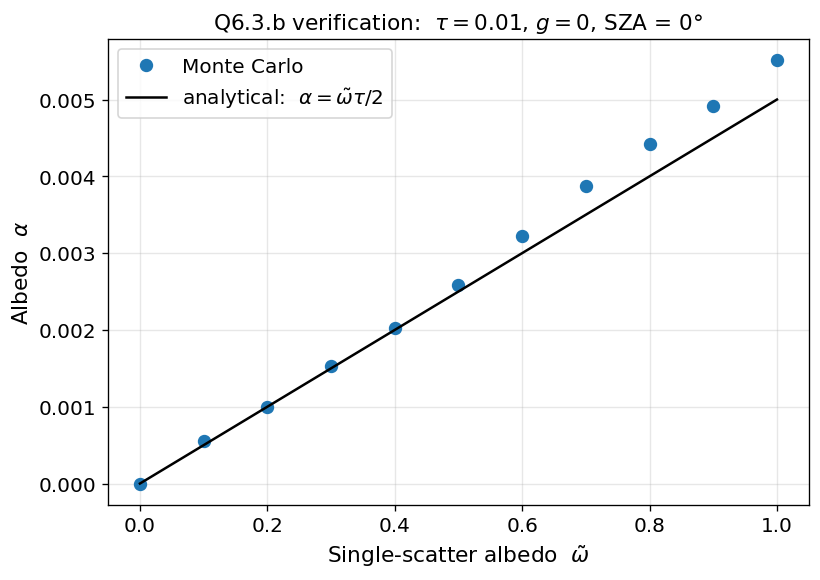

In [30]:
tau = 0.01
g = 0
sza = 0
omegas = np.linspace(0.0, 1.0, 11)

N_PHOT = 100_000
alb_mc = np.array([
    run_monte_carlo_hg(tau_star=tau, sza_deg=sza, omega=w, g=g,
                       n_photons=N_PHOT,
                       rng=np.random.default_rng(seed=42))['albedo']
    for w in omegas
])

# Analytical prediction
def albedo_approx(tau, omega):
    return tau * omega / 2.0

alb_pred = albedo_approx(tau, omegas)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(omegas, alb_mc,  'o', color='C0', label='Monte Carlo', ms=7)
ax.plot(omegas, alb_pred, '-', color='k',  lw=1.5,
        label=r'analytical:  $\alpha = \tilde\omega\tau/2$')
ax.set_xlabel(r'Single-scatter albedo  $\tilde\omega$')
ax.set_ylabel(r'Albedo  $\alpha$')
ax.set_title(rf'Q6.3.b verification:  $\tau = {tau}$, $g = {g}$, SZA = {sza:g}°')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/q6_3b_albedo_vs_omega.png', bbox_inches='tight')
plt.show()


### 6.3.c — Functional relationship $f(g) = \alpha / (\tau\tilde\omega)$

At $\tau \ll 1$, $\mu_0 = 1$, I pick oned representative $\tilde\omega$ and varied $g$ to get an array of albedos then I plotted $f(g)$ as a function of g using the albedos from the MC model. 

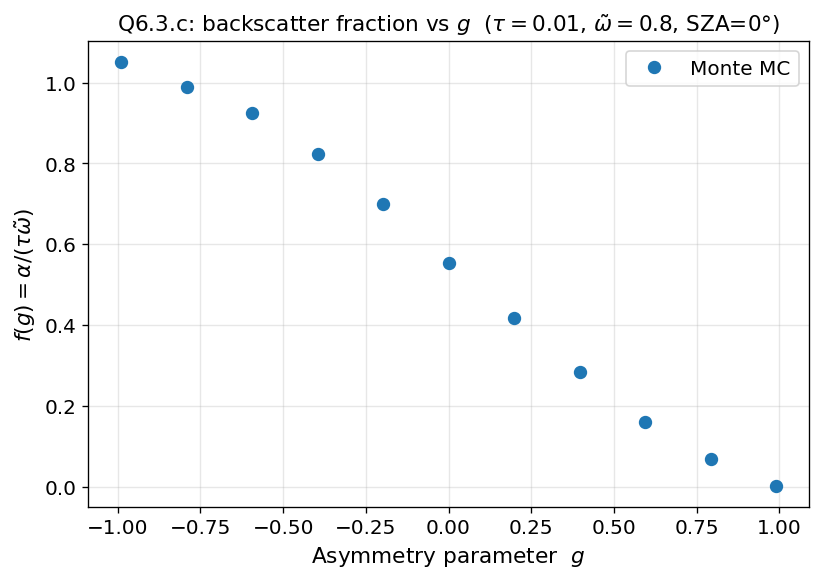

In [31]:
# **Task:** at $\tau \ll 1$, $\mu_0 = 1$, pick one representative $\tilde\omega$ and vary $g$ from (say) $-1$ to $+1$. Plot $f(g)$ and describe its functional form.
tau = 0.01
gs = np.linspace(-0.99, 0.99, 11)
sza = 0
omega = 0.8
# f(g) = α / τ ˜ω 
alb_mc = np.array([
    run_monte_carlo_hg(tau_star=tau, sza_deg=sza, omega=omega, g=g,
                       n_photons=N_PHOT,
                       rng=np.random.default_rng(seed=42))['albedo']
    for g in gs
])
f_g = alb_mc / (tau * omega)   # the function

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gs, f_g,  'o', color='C0', label='Monte MC', ms=7)  
ax.set_xlabel(r'Asymmetry parameter  $g$')
ax.set_ylabel(r'$f(g) = \alpha / (\tau\tilde\omega)$')
ax.set_title(rf'Q6.3.c: backscatter fraction vs $g$  '
             rf'($\tau={tau}$, $\tilde\omega={omega}$, SZA={sza}°)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/q6_3c_f_vs_g.png', bbox_inches='tight')
plt.show()

## this looks like a semi straight line with a near constant negative slope, meaning that as g increases , the backscatter fraction decreases.

### 6.3.d — Backscatter function $B(g)$

Define
$$B(g) \;=\; \frac{1}{2}\int_{-1}^{0} P_{\rm HG}(\mu, g)\,d\mu.$$

- when I computed the integral to solve for B I got:
$$\boxed{B(g) \;=\; \frac{1}{2g}\left[\frac{1 - g^2}{\sqrt{1 + g^2}} \;-\; (1 - g)\right].}$$

See attached photo at the end of the nb to see my work

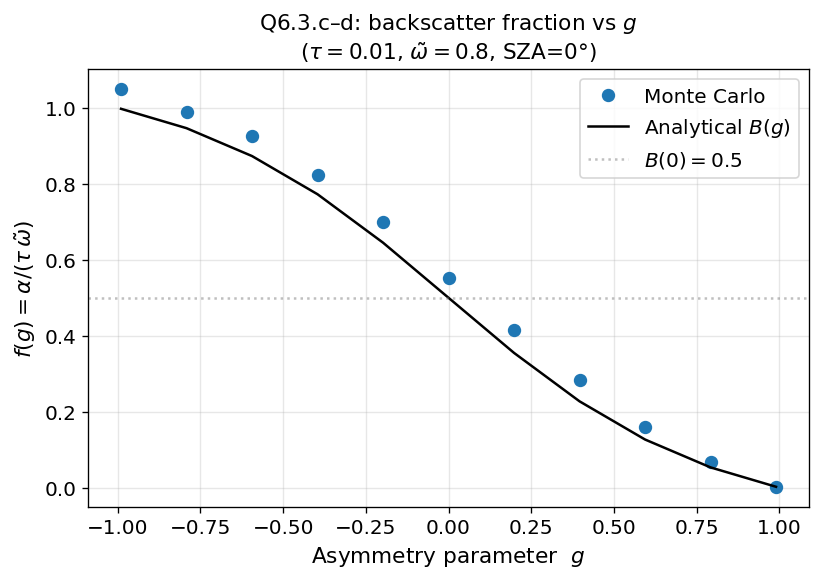

In [32]:
# closed form B(g)
def analytical_b_g(g):
    g = np.asarray(g, dtype=float)
    
    if g.ndim == 0:                       
        if abs(g) < 1e-6:
            return 0.5                    
        return float(1/(2*g) * ((1 - g**2)/np.sqrt(1 + g**2) - (1 - g)))
    
    
    out = np.empty_like(g) # lets arrays be the output of this function be the same shape as the input g, whether g is a scalar or an array.
    small = np.abs(g) < 1e-6 # isotropic limit is a special case that we have to handle separately to avoid divide-by-zero, but we want the output of this function to be the same shape as the input g, whether g is a scalar or an array. So we create an output array of the same shape as g, and then fill in the values for the small g's with 0.5, and then fill in the rest with the general formula.
    out[small] = 0.5
    g_safe = g[~small]
    out[~small] = 1/(2*g_safe) * ((1 - g_safe**2)/np.sqrt(1 + g_safe**2) - (1 - g_safe))
    return out


# compared to MC
b_g_pred = analytical_b_g(gs)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gs, f_g,      'o', color='C0', label='Monte Carlo', ms=7)
ax.plot(gs, b_g_pred, '-', color='k',  lw=1.5, label=r'Analytical $B(g)$')
ax.axhline(0.5, color='gray', ls=':', alpha=0.5, label=r'$B(0) = 0.5$')

ax.set_xlabel(r'Asymmetry parameter  $g$')
ax.set_ylabel(r'$f(g) = \alpha / (\tau\,\tilde\omega)$')
ax.set_title(rf'Q6.3.c–d: backscatter fraction vs $g$'
             '\n'
             rf'($\tau={tau}$, $\tilde\omega={omega}$, SZA={sza}°)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/q6_3c_f_vs_g_with_analytical.png', bbox_inches='tight')
plt.show()

### Both of MC model f(g) and analytical B(g) show the same relationship for an optically thin atmosphere with the SZA at 0

### 6.3.e — Own Question

**Question**: Should the Rayleigh phase function be different than the HG phase function for g =0? 

**Hypothesis** : I think both of phase functions should be equal when g = 0. 

The Rayleigh phase function is
$$P_{\rm Ray}(\cos\Theta) \;=\; \frac{3}{4} (1 + cos^2 \theta).$$
- integrate $$P_{\rm Ray}(\cos\Theta) \;=\; \frac{3}{4} (1 + cos^2 \theta).$$ between -1 and cos theta, as a function of cos of theta


$$C(\cos\Theta) \;=\; \frac{1}{2}\int_{-1}^{\cos\Theta} P_{\rm Ray}(x)\,dx \;=\; \frac{3\cos\Theta + \cos^3\Theta}{8} \;+\; \frac{1}{2}.$$


**Step 4 — Invert the CDF to solve for $\cos\Theta$:**

Set $C(\cos\Theta) = \zeta$ (a uniform random number on $[0, 1]$) and multiply through by 8:

$$\cos^3\Theta + 3\cos\Theta \;=\; 8\zeta - 4.$$

I used AI to help me solve for cos/theta and it said that: 

This is a **depressed cubic** of the form $t^3 + pt + q = 0$ with $t = \cos\Theta$, $p = 3$, $q = 4 - 8\zeta$. Using Cardano's formula and letting $u = 4\zeta - 2$:

$$\boxed{\cos\Theta \;=\; \sqrt[3]{u + \sqrt{u^2 + 1}} \;-\; \sqrt[3]{-u + \sqrt{u^2 + 1}}, \qquad u = 4\zeta - 2.}$$

The discriminant $u^2 + 1$ is always positive, so the cube roots are always real — no complex-number gymnastics required.

In [33]:
# write new rayleigh sampling function for 6.4.a
def sample_scatter_angles_rayleigh_cdf(rng):
    """Sample cos(Theta) from the Rayleigh phase function via the analytical
    CDF inversion (Cardano).
    """
    zeta = rng.uniform(0.0, 1.0)
    u    = 4.0 * zeta - 2.0
    s    = np.sqrt(u**2 + 1.0)
    # np.cbrt handles negative arguments correctly (real cube root)
    cos_theta = np.cbrt(u + s) - np.cbrt(-u + s)
    cos_theta = float(np.clip(cos_theta, -1.0, 1.0))
    phi = rng.uniform(0.0, 2.0 * np.pi)
    return cos_theta, phi

# make new MC for Rayleigh phase function 

def run_monte_carlo_rayleigh(tau_star, sza_deg, omega,
                             n_photons=N_PHOTONS, rng=rng, n_traces=0):
    """HW3 Part II 6.4 — multiple-scattering MC with Rayleigh phase function.

    Same structure as run_monte_carlo_hg, but uses
    sample_scatter_angles_rayleigh_cdf for the scattering angle instead
    of the Henyey-Greenstein sampler. Rayleigh has g = 0 by symmetry
    but a different shape than isotropic (peaks at cos(Theta) = ±1,
    minimum at cos(Theta) = 0).

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : absorbed inside the atmosphere

    If n_traces > 0, records the (x, tau_pos) trajectory of the first n_traces
    photons and returns them under the 'trajectories' key.
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
                'trajectories': []}

    # Initial photon direction in model coordinates (downward at SZA).
    # By azimuthal symmetry we can pick phi0 = 0 without loss of generality.
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct     = 0
    n_diffuse    = 0
    n_reflected  = 0
    n_absorbed   = 0
    trajectories = []   # only filled for the first n_traces photons

    for i in range(n_photons):
        record_this = (i < n_traces)

        k         = k_init.copy()
        x         = 0.0     # horizontal position (only used when recording)
        tau_pos   = 0.0     # vertical optical depth so far (0 = TOA, tau_star = surface)
        scattered = False   # has this photon ever scattered?
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            # --- sample optical path length along current direction ---
            ds = sample_path_length(rng)

            # --- convert along-path tau to a vertical-tau increment ---
            dtau_vert = -ds * k[2]      # down = positive depth
            tau_pos_n = tau_pos + dtau_vert
            dx        =  ds * k[0]
            x_n       = x + dx

            # --- escape: surface ---
            if tau_pos_n >= tau_star:
                if record_this:
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1
                else:
                    n_direct += 1
                break

            # --- escape: top of atmosphere ---
            if tau_pos_n <= 0.0:
                if record_this:
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- otherwise the photon interacts inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?
            if rng.uniform(0.0, 1.0) >= omega:
                n_absorbed += 1
                break

            # 6.4: sample new scattering angles from the Rayleigh phase function
            cos_th, phi = sample_scatter_angles_rayleigh_cdf(rng)

            # 5.1.d: rotate into model coordinates -> new propagation direction
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True
            # 5.1.e: loop continues — sample a new path length next iteration

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,   # list of (Npts, 2) arrays; empty if n_traces=0
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
    }


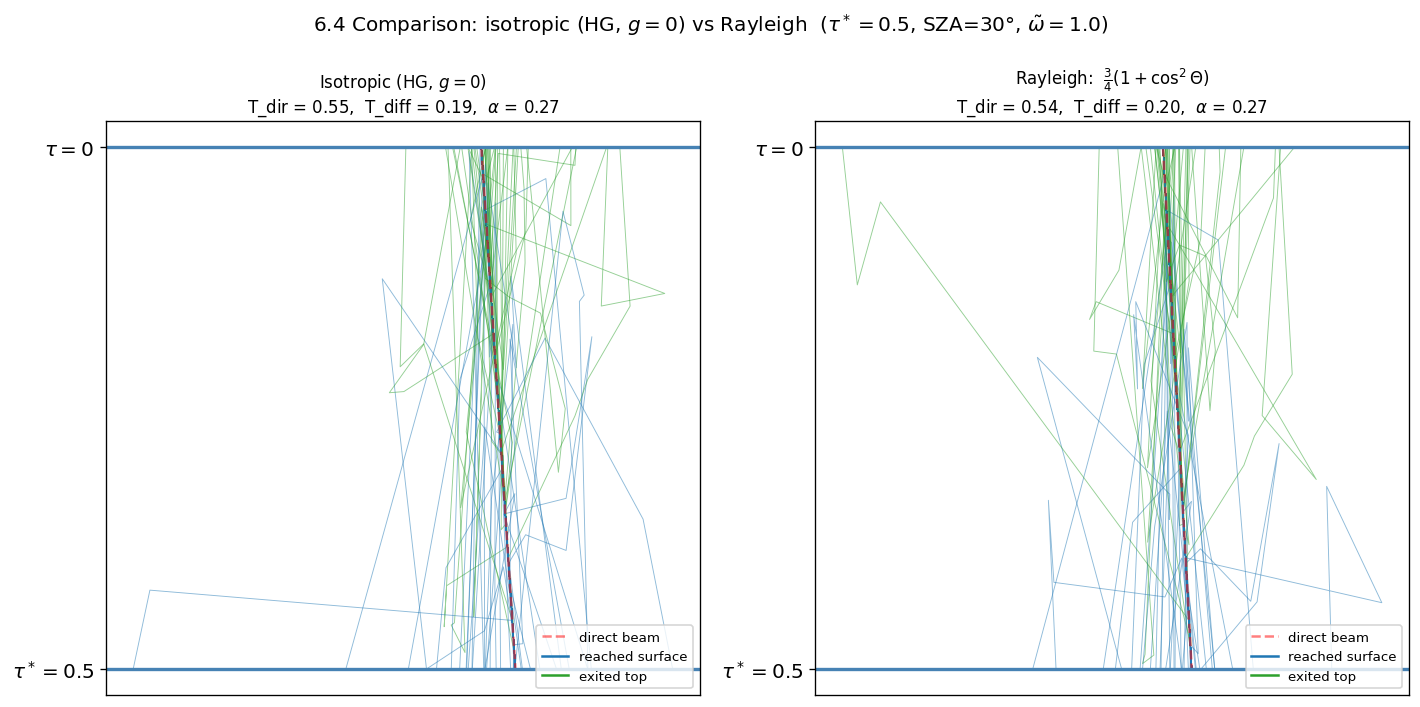

In [34]:
tau_star = 0.5
sza_deg  = 30.0
omega    = 1.0     # pure scattering — isolates the phase function effect
n_traces = 200

# Run both models with identical seed for a fair visual comparison
hg_iso = run_monte_carlo_hg(tau_star=tau_star, sza_deg=sza_deg,
                            omega=omega, g=0.0,
                            n_photons=n_traces, n_traces=n_traces,
                            rng=np.random.default_rng(seed=11))

ray = run_monte_carlo_rayleigh(tau_star=tau_star, sza_deg=sza_deg,
                               omega=omega,
                               n_photons=n_traces, n_traces=n_traces,
                               rng=np.random.default_rng(seed=11))

# Direct-beam geometry (same for both panels)
sin_sza = np.sin(np.deg2rad(sza_deg))
mu0     = np.cos(np.deg2rad(sza_deg))
x_end   = (tau_star / mu0) * sin_sza

cases = [
    {'out': hg_iso, 'title': r'Isotropic (HG, $g = 0$)'},
    {'out': ray,    'title': r'Rayleigh:  $\frac{3}{4}(1+\cos^2\Theta)$'},
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, case in zip(axes, cases):
    out = case['out']

    # Color trajectories by final fate
    for traj in out['trajectories']:
        end_tau = traj[-1, 1]
        if   np.isclose(end_tau, tau_star): color = 'C0'    # reached surface
        elif np.isclose(end_tau, 0):        color = 'C2'    # exited top
        else:                               color = 'gray'  # absorbed
        ax.plot(traj[:, 0], traj[:, 1], '-', color=color, lw=0.55, alpha=0.5)

    # Direct beam reference
    ax.plot([0, x_end], [0, tau_star], 'r--', lw=1.5, alpha=0.5, label='direct beam')

    # Atmosphere boundaries
    ax.axhline(0,        color='steelblue', lw=2)
    ax.axhline(tau_star, color='steelblue', lw=2)
    ax.invert_yaxis()
    ax.set_yticks([0, tau_star])
    ax.set_yticklabels([r'$\tau = 0$', rf'$\tau^* = {tau_star:g}$'])
    ax.set_xticks([])

    ax.set_title(f"{case['title']}\n"
                 f"T_dir = {out['T_direct']:.2f},  "
                 f"T_diff = {out['T_diffuse']:.2f},  "
                 rf"$\alpha$ = {out['albedo']:.2f}",
                 fontsize=10)

    # Dummy legend entries for the fate colors
    ax.plot([], [], '-', color='C0', lw=1.5, label='reached surface')
    ax.plot([], [], '-', color='C2', lw=1.5, label='exited top')
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle(rf'6.4 Comparison: isotropic (HG, $g=0$) vs Rayleigh  '
             rf'($\tau^*={tau_star}$, SZA={sza_deg:g}°, $\tilde\omega={omega}$)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/q6_4_iso_vs_rayleigh.png', bbox_inches='tight')
plt.show()

# The direct and diffuse transmittance for Rayleigh phase function and for the HG with g=0 (isotropic) are almost the same with a difference of 0.01 and both of the albeods are the same. It is interesting that both can produce the same transmittance and albedo values but have, different photon paths. They have different photon paths due to the definition of Rayleigh and isotropic. Opposed to uniform isotropic scattering each scatter is more likely to be a small forward or backward reversal for Rayleigh scattering. 

###  Derivation Photos
#6.1 a

![6.1.a derivation page 1](figures/6_1a_derivation_p1.png)

![6.1.a derivation page 2](figures/6_1a_derivation_p2.png)
## 6.3.d 



![Backscatter B(g) derivation](figures/6_3d_Bg_derivation.png)

---
## AI Usage Statement

**Tool used:** Claude (Anthropic)

**How it was used:** 

I used AI to help me solve for cos\theta for my own question in the last part of the homework. I also used AI to help make the verification: HG phase function plot. Used AI to help make the MC function in the last homework but since this, homework we just swapped out the cosine function it was easy to implement myself. 

**What I checked independently:**

When I solved for both CDF's I did that on my own, even though I know AI can solve an integral I through verification plots I was able to trust my work. 

